In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import mesa

In [2]:
class MoneyAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1

    def exchange(self):
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            if other_agent is not None:
                other_agent.wealth += 1
                self.wealth -= 1

class MoneyModel(mesa.Model):
    def __init__(self, n=10, rng=None):
        super().__init__(rng=rng)
        self.num_agents = n
        MoneyAgent.create_agents(model=self, n=n)

    def step(self):
        self.agents.shuffle_do("exchange")

In [3]:
all_wealth = []

for _ in range(100):
    model = MoneyModel(10)
    model.run_for(30)

    for agent in model.agents:
        all_wealth.append(agent.wealth)

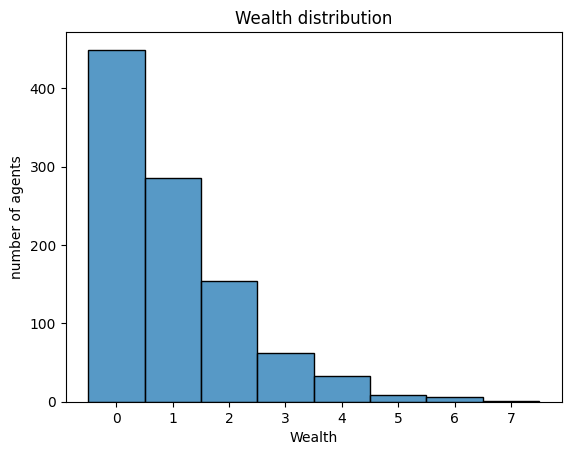

In [4]:
g = sns.histplot(all_wealth, discrete=True)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");